# Second run using more complex tensor

We present here a simple example to show the basic functionalities. It uses a random input tensor, more complex examples can be explored in the other [notebook](SWoTTeD_module_example.ipynb).

## Exemple d'utilisation de trajectoryclusteringanalysis (multidimensionnel)

Cette section illustre un workflow complet du package `trajectoryclusteringanalysis` :
1. Initialiser TCA en mode multidimensionnel
2. Construire le tenseur $\mathbf{X}\in\{0,1\}^{K\times N\times T}$ (patient × événement × temps)
3. Apprendre la decomposition SWoTTeD
4. Extraire les intensites de phenotypes et clusteriser les patients

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
from pathlib import Path

# Locate the repository data folder regardless of current working directory
target_name = "multidimensional_data"
data_dir = None
for base in [Path.cwd(), *Path.cwd().parents]:
    candidate = base / "data"
    if (candidate / f"{target_name}.csv").exists():
        data_dir = candidate
        break

if data_dir is None:
    raise FileNotFoundError(
        f"Could not find a 'data' folder containing {target_name}.csv. "
        f"Current working directory: {Path.cwd()}"
    )

csv_path = data_dir / f"{target_name}.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(
        f"'{csv_path}' does not exist."
    )

print(f"Loaded data from: {csv_path}")

Loaded data from: c:\Users\nicolas.grevet\dev\TrajectoryClusteringAnalysis.worktrees\copilot-worktree-2026-04-13T12-30-11\data\multidimensional_data.csv


In [2]:
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [4]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [6]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


## Guide rapide: pipeline TCA multidimensionnel

Dans cette partie, on suit un enchainement simple et reproductible:
1. Configurer l'import du package (local)
2. Initialiser `TCA` en mode multidimensionnel
3. Construire le tenseur
4. Entrainer SWoTTeD
5. Clusteriser les intensites de phenotypes

In [8]:
from pathlib import Path
import sys

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

Using local package from: c:\Users\nicolas.grevet\dev\TrajectoryClusteringAnalysis.worktrees\copilot-worktree-2026-04-13T12-30-11\src


In [9]:
from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

### 2) Initialiser TCA (mode multidimensionnel)

`TCA` encapsule la préparation des données, la décomposition SWoTTeD et les outils de clustering/visualisation.

In [10]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


### 3) Construire le tenseur multidimensionnel

Transformation du format long (`ID_PATIENT`, `Time`, `Event`) vers un tenseur binaire `(K, N, T)`.

In [11]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


### 4) Parametrer et entrainer SWoTTeD

Commence avec peu d'epochs pour une demo rapide, puis augmente pour ameliorer la qualite.

In [12]:
# Hyperparametres de la demo
rank = 3
time_window_length = 3
reg_term_ns = 0.5
reg_term_s = 0.5
metric = 'Bernoulli'
learning_rate = 1e-2
n_epochs = 30  # 30 pour demo rapide, 100+ pour entrainement plus stable

Patient utilise pour la visualisation: 8


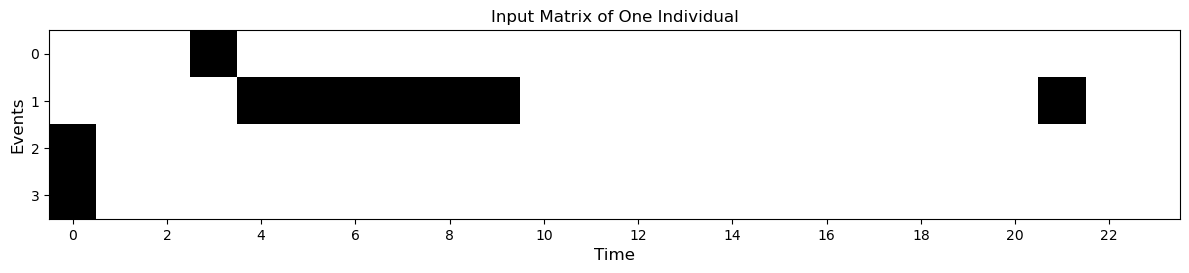

In [13]:
patient_index = int(patients_with_all_events[0])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded)

In [14]:
tca.analyzer.fit_swotted_decomposition(tensor,
                                       rank,
                                       time_window_length,
                                       reg_term_ns, 
                                       reg_term_s, 
                                       metric, 
                                       learning_rate, 
                                       n_epochs)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWi

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Decomposed into 1336 pathways with rank 3 and time window length 3
FIT metric for the entire dataset: -0.0656
success_rate :-0.15659276452873372


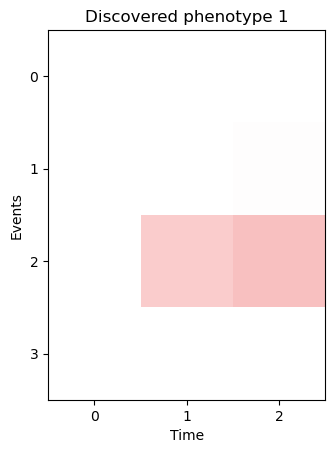

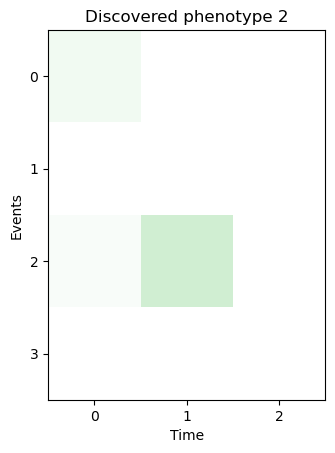

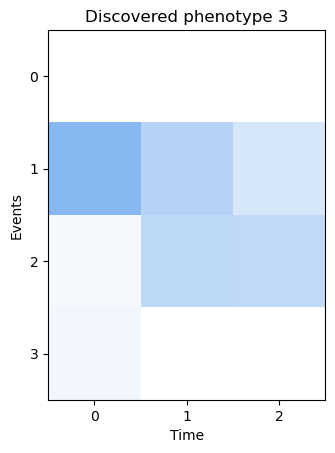

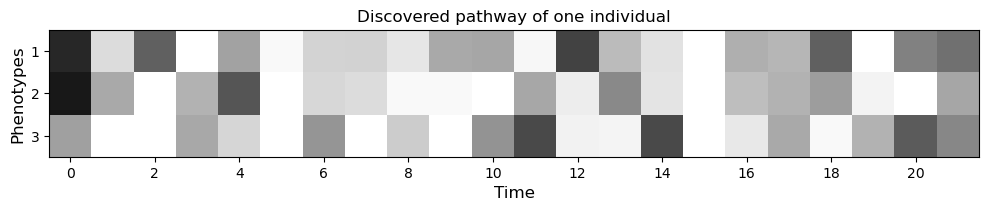

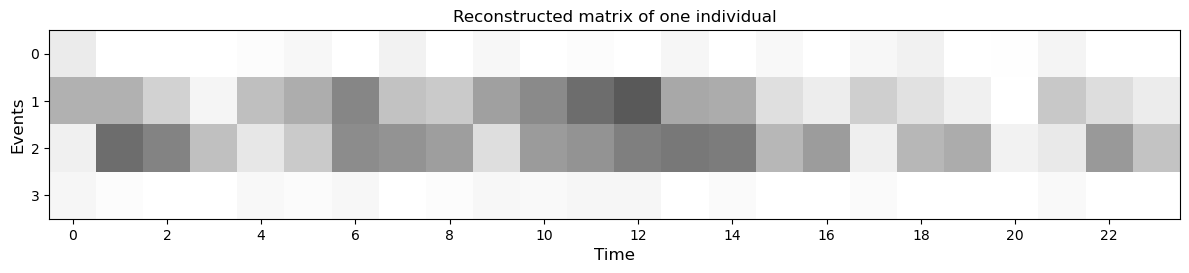

In [15]:
tca.analyzer.get_decomposition_results(labels=tca.label_to_encoded, id=patient_index)

In [16]:
from sklearn.preprocessing import StandardScaler

ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=StandardScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,1.041217,-0.240939,-0.640132,1
1,-0.525820,0.546464,0.686859,2
2,1.213404,0.614011,1.837701,3
3,1.818520,-0.559163,0.812819,4
4,0.150219,2.189097,-0.107967,5


### 5) Extraire les intensites et clusteriser

On resume chaque patient par ses intensites de phenotypes, puis on applique un clustering hierarchique.

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.00 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\nicolas.grevet\dev\TrajectoryClusteringAnalysis.worktrees\copilot-worktree-2026-04-13T12-30-11\src\trajectoryclusteringanalysis\unidimensional\clustering.py:228: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


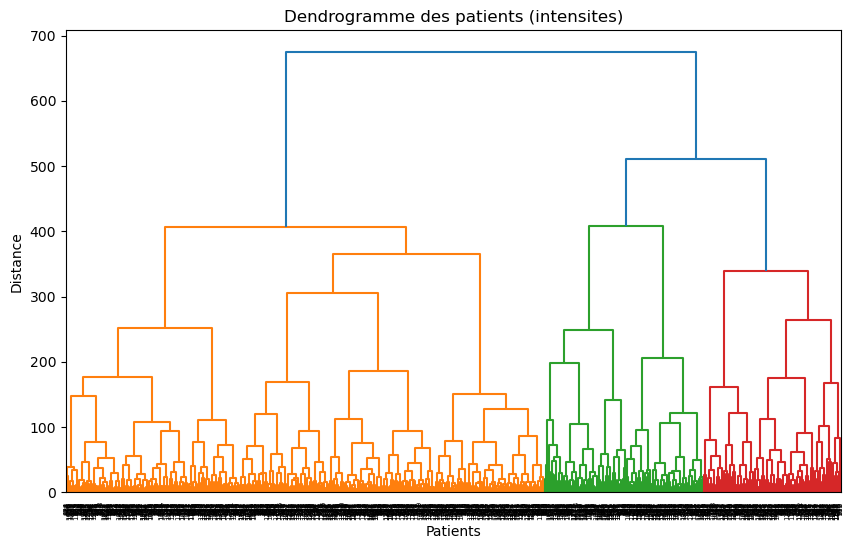

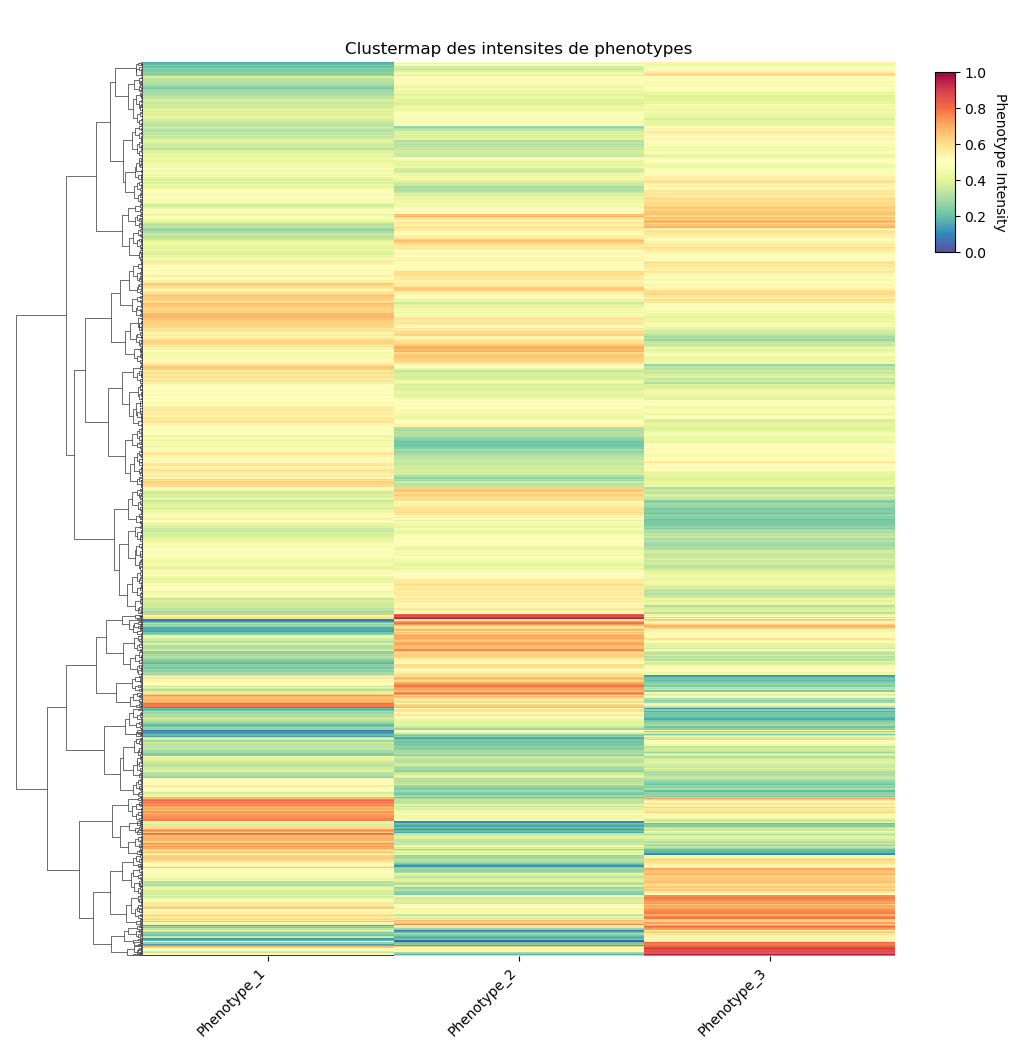

Effectifs par cluster:
1    825
2    141
3    133
4    237
Name: count, dtype: int64


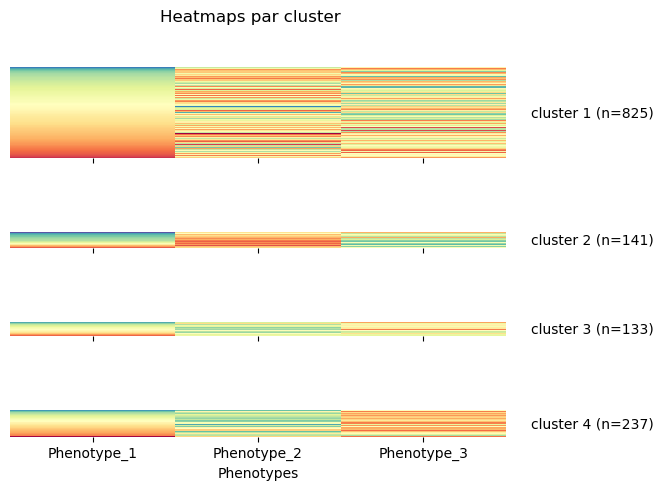

In [17]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)

# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')